In [127]:
# @launchit.collected

In [128]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

import sys
import os
from collections import namedtuple # @launchit.collect
from pathlib import Path
import json
import datetime
import pprint
from functools import cache
import re
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append(project_root_path)
from lib.utils import *
from lib.logging import *
from lib.model_registry import *
import lib.launchit # @launchit.disable

# Setup

In [129]:
LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, data_path, sparsenet_path, metrics_path, ' + 
                    'notebook_fname, notebook_name, is_cuda, cuda_device')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    data_path=os.path.join(project_root_path, 'data'),
    sparsenet_path=os.path.join(project_root_path, 'data', 'sparsenet'),
    metrics_path=os.path.expanduser('~/tensorboard'),
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu'
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=notebook_name)

print('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
print('')

# @launchit.disable
# @launchit.collect
MODEL_INSTANCE_INFO = namedtuple('ModelInstanceInfo', 'group_uri, name, version, main_asset_fname')(
    group_uri='${MODEL_GROUP_URI}',
    name='${MODEL_NAME}',
    version=0,
    main_asset_fname='${LAUNCHIT_FNAME}'
)
# @launchit.stop

MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(group_uri=f'{CONFIG.project_root_uri}.{os.path.basename(os.path.dirname(notebook_fname))}')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(name=CONFIG.notebook_name)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(main_asset_fname=CONFIG.notebook_fname)
# @launchit.stop

print('MODEL_INSTANCE_INFO=\n' + pprint.pformat(MODEL_INSTANCE_INFO._asdict()))

MODEL_REGISTRY = ModelRegistry(MODEL_INSTANCE_INFO.group_uri)

CONFIG=
{'cuda_device': 'cpu',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'is_cuda': False,
 'metrics_path': '/home/misha/tensorboard',
 'notebook_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_01.ipynb',
 'notebook_name': 's3_stacked_dae_01',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'sparsenet_path': '/home/misha/dev/mine/neurovision/data/sparsenet'}

MODEL_INSTANCE_INFO=
{'group_uri': 'com.develorium.neurovision.denoise',
 'main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_01.ipynb',
 'name': 's3_stacked_dae_01',
 'version': 0}


# Launchit

In [130]:
# @launchit.disable
launchit_t0 = time.time()

In [131]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    expandvars = dict(
        MODEL_GROUP_URI=MODEL_INSTANCE_INFO.group_uri,
        MODEL_NAME=MODEL_INSTANCE_INFO.name,
    )
    lib.launchit.launchit(CONFIG.notebook_fname, expandvars)
else:
    print('Skip launchit due to mass "Run Cells"')

Skip launchit due to mass "Run Cells"


# Hypers

In [132]:
# @launchit.disable
# @launchit.collect
HP = namedtuple('HyperParameters', [
    'images_slot',
    'dataset_size',
    'dataset_preprocessing',
    'patch_size',
    'noise',
    'daes_count',
    'filters_count',
    'batch_size',
    'trained_dae_inds',
    'epochs_count',
    'learn_rate', 
], defaults=[None] * 11)(
    images_slot='WHITENED'
)

# Images

In [133]:
def add_images_to_lib(images, tag):
    IMAGES_LIB[tag] = dict(images=images, image_stds=images.reshape(images.shape[0], -1).std(axis=1))

In [134]:
IMAGES_LIB = {
    'RAW': dict(fname='IMAGES_RAW.mat', mat_name='IMAGESr'),
    'WHITENED': dict(fname='IMAGES.mat', mat_name='IMAGES'),
}

for k in IMAGES_LIB:
    fname = IMAGES_LIB[k]['fname']
    mat_name = IMAGES_LIB[k]['mat_name']
    mat = scipy.io.loadmat(os.path.join(CONFIG.sparsenet_path, fname))
    images = mat[mat_name]
    images = np.moveaxis(images, [2], [0])
    add_images_to_lib(images, k)

# Patching

In [135]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

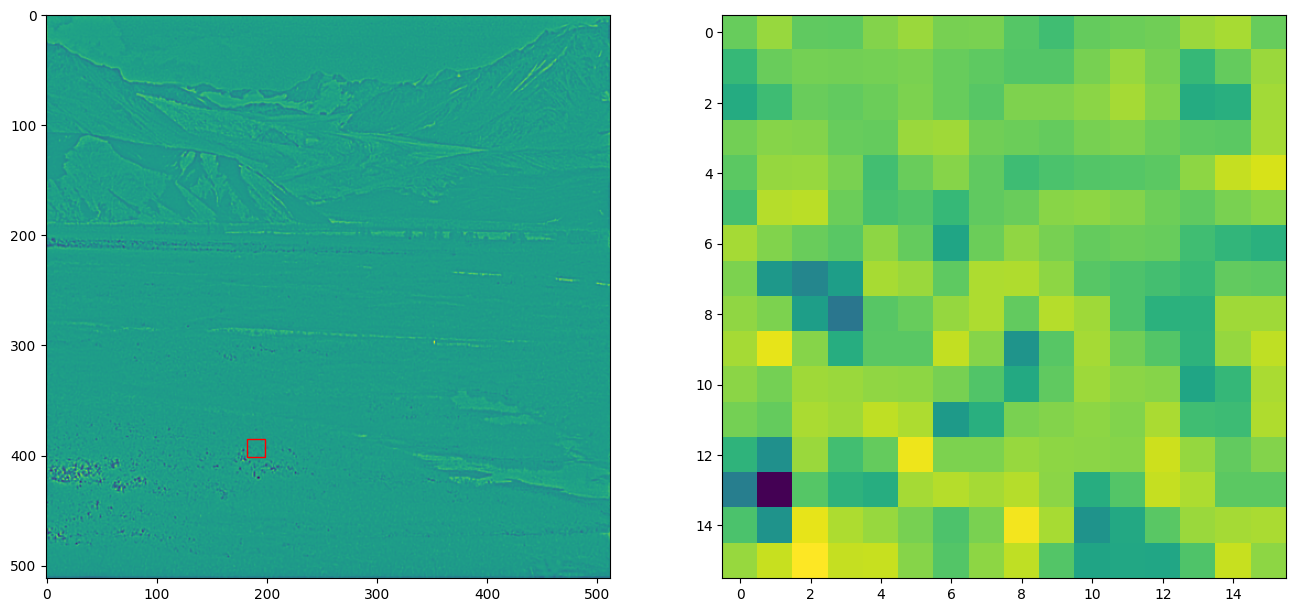

In [136]:
# @launchit.disable
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(images[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Noising

## gauss_noise

In [137]:
def gauss_noise(items, gadds_tab):
    if items.ndim == 2:
        assert items.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {gadds_tab.shape[1]}'
        items_count = len(items)
        noise = gadds_tab[RNG.choice(len(gadds_tab), items_count)]
    elif items.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        return items + noise
    elif isinstance(items, torch.Tensor):
        return items + torch.tensor(noise, device=items.device, dtype=items.dtype)

## masking_noise

In [138]:
def masking_noise(items, masks_tab, fill_value=0):
    if items.ndim == 2:
        assert items.shape[1] == masks_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {masks_tab.shape[1]}'
        items_count = len(items)
        mask_inds = RNG.choice(len(masks_tab), items_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif items.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        noised = items.copy()
    elif isinstance(items, torch.Tensor):
        noised = items.clone()
    else:
        assert False, f'Unsupported type(items): {type(items)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [139]:
def generate_zmasks(ν, item_size, count):
    assert 0 <= ν <= 1
    zero_inds_count = int(ν * item_size)
    zmasks = np.full((count, item_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(item_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

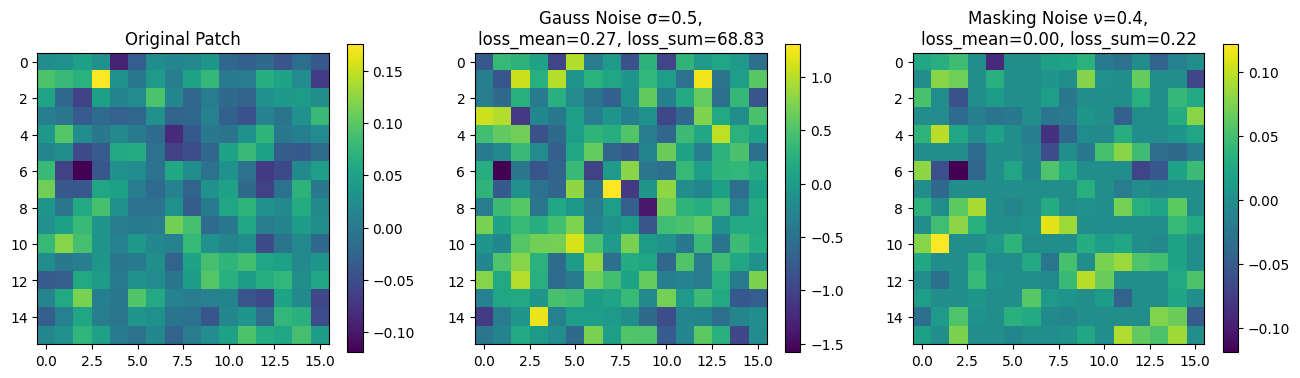

In [140]:
# @launchit.disable
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original Patch')
im = ax1.imshow(patch);
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, patch.shape[0]**2))
noised = gauss_noise(patch.ravel(), gadds)
noised = noised.reshape(patch.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax2.imshow(noised);
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(ν, patch.shape[1] ** 2, 100)
noised = masking_noise(patch.ravel(), zmasks, fill_value=0)
noised = noised.reshape(patch.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax3.imshow(noised);
fig.colorbar(im, ax=ax3, shrink=.5);

# Dataset

In [141]:
# @launchit.disable
# @launchit.collect
HP = HP._replace(
    dataset_size=1_000_000,
    dataset_preprocessing='NONE', # NONE, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
    patch_size=12,
)

## Populate

In [142]:
@cache
def generate_dataset(dataset_size, patch_size, images_slot):
    dataset_rng = np.random.default_rng(82)
    images = IMAGES_LIB[images_slot]['images']
    dataset = []
    
    for i in tqdm(range(dataset_size)):
        patch = extract_image_patch(images, patch_size, rng=dataset_rng).patch
        dataset.append(patch.ravel())
    
    return np.array(dataset)

In [143]:
fname = os.path.join(CONFIG.data_path, 'denoise', f'dataset-{HP.images_slot.lower()}-{HP.patch_size}.pkl')

if os.path.exists(fname):
    with open(fname, 'rb') as f:
        DATASET = pickle.load(f)
        
    print(f'Dataset loaded from "{fname}"')
else:
    DATASET = generate_dataset(HP.dataset_size, HP.patch_size, HP.images_slot)

    os.makedirs(os.path.dirname(fname), exist_ok=True)

    with open(fname, 'wb') as f:
        pickle.dump(DATASET, f)

    print(f'Dataset saved to "{fname}"')

Dataset loaded from "/home/misha/dev/mine/neurovision/data/denoise/dataset-whitened-12.pkl"


## Preprocess

In [144]:
match HP.dataset_preprocessing:
    case 'STANDARDIZE':
        DATASET_SCALER = StandardScaler()
        DATASET = DATASET_SCALER.fit_transform(DATASET)
    case 'ZCA_WHITEN':
        DATASET_SCALER = StandardScaler(with_std=False)
        DATASET = DATASET_SCALER.fit_transform(DATASET)
        
        Σ = np.cov(DATASET, rowvar=False)
        u, s, _ = np.linalg.svd(Σ)
        DATASET = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ DATASET.T).T
    case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
        DATASET_SCALER = StandardScaler(with_std=False)
        DATASET = DATASET_SCALER.fit_transform(DATASET)

        Σ = np.cov(DATASET, rowvar=False)
        eigvals, eigvecs = np.linalg.eig(Σ)
        eigvals_order = np.argsort(-eigvals)
        wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
        eigvals_w = eigvals.copy()
        eigvals_w[wipeout_inds] = 0
        
        R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
        S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
        R_inv = R.T
        W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
        DATASET = (W @ DATASET.T).T
    case 'NONE':
        pass
    case _:
        assert False, f'Unsupported dataset_preprocessing={HP.dataset_preprocessing}'
    
DATASET = torch.Tensor(DATASET)
DATASET = DATASET.contiguous() # force dense memory layout (speeds up DataLoader x2)

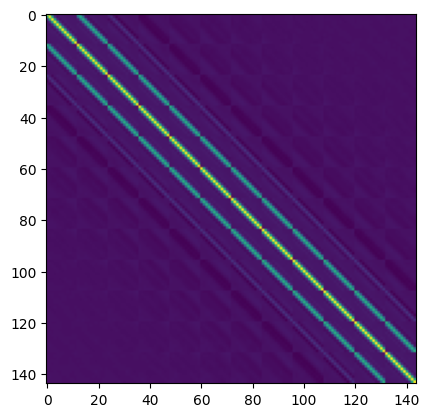

In [145]:
# @launchit.disable
plt.imshow(np.cov(DATASET, rowvar=False));

# Model

In [165]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count):
        super().__init__()
        self.filters = tnn.Linear(inp_dims_count, hiddens_count)
        self.decoder = tnn.Linear(hiddens_count, inp_dims_count)

        bound = 1 / np.sqrt(inp_dims_count)
        self.filters.weight.data.uniform_(-bound, bound)
        bound = 1 / np.sqrt(hiddens_count)
        self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        res = self.encode(inp)
        res = self.decode(res)
        return res

    def encode(self, inp):
        return tnnf.sigmoid(self.filters(inp))

    def decode(self, inp):
        return self.decoder(inp)

class StackedDAE(tnn.Module):
    def __init__(self, daes_count, inp_dims_count, hiddens_count):
        super().__init__()
        self.daes = tnn.ModuleList()

        current_inp_dims_count = inp_dims_count
        
        for i in range(daes_count):
            dae = DenoiseAutoencoder(current_inp_dims_count, hiddens_count)
            current_inp_dims_count = hiddens_count
            self.daes.append(dae)

In [166]:
model = StackedDAE(3, 144, 200)
sum([p.numel() for p in model.parameters()])

218744

In [167]:
data_loader = DataLoader(DATASET, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(model.daes)):
        save_shape = batch.shape
        batch = model.daes[i].encode(batch)
        print(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(model.daes))):
        save_shape = batch.shape
        batch = model.daes[i].decode(batch)
        print(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 144])->torch.Size([100, 200])
Encoding by DAE_1, batch shape=torch.Size([100, 200])->torch.Size([100, 200])
Encoding by DAE_2, batch shape=torch.Size([100, 200])->torch.Size([100, 200])
Decoding by DAE_2, batch shape=torch.Size([100, 200])->torch.Size([100, 200])
Decoding by DAE_1, batch shape=torch.Size([100, 200])->torch.Size([100, 200])
Decoding by DAE_0, batch shape=torch.Size([100, 200])->torch.Size([100, 144])


# Training

In [160]:
@cache
def gadds(σ, item_size, gadds_count):
    return RNG.normal(0, σ, (gadds_count, item_size)).astype(float) 

@cache
def zmasks(ν, item_size, masks_count):
    return generate_zmasks(ν, item_size, masks_count)

In [161]:
noise_funcs = {
    'Gauss_0.5': lambda items: gauss_noise(items, gadds(0.5, items.shape[1], HP.dataset_size)),
    'Masking_0.1': lambda items: masking_noise(items, zmasks(0.1, items.shape[1], HP.dataset_size)),
    'Masking_0.25': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], HP.dataset_size)),
    'Masking_0.25_1': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], HP.dataset_size), fill_value=1),
    'Masking_0.4': lambda items: masking_noise(items, zmasks(0.4, items.shape[1], HP.dataset_size)),
    'Masking_0.55': lambda items: masking_noise(items, zmasks(0.55, items.shape[1], HP.dataset_size)),
}
# @launchit.disable
# @launchit.collect
HP = HP._replace(
    daes_count=3,
    filters_count=200,
    batch_size=10_000,
    epochs_count=500,
    learn_rate=0.01,
    noise='Masking_0.55',
)
HP = HP._replace(
    trained_dae_inds=','.join(map(str, range(HP.daes_count)))
)
# @launchit.stop
pprint.pprint(HP._asdict())

{'batch_size': 10000,
 'daes_count': 3,
 'dataset_preprocessing': 'NONE',
 'dataset_size': 1000000,
 'epochs_count': 500,
 'filters_count': 200,
 'images_slot': 'WHITENED',
 'learn_rate': 0.01,
 'noise': 'Masking_0.55',
 'patch_size': 12,
 'trained_dae_inds': '0,1,2'}


In [ ]:
data_loader = DataLoader(DATASET, batch_size=HP.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
model = StackedDAE(HP.daes_count, HP.patch_size**2, HP.filters_count).to(device=CONFIG.cuda_device)
optimizer = topt.Adam(model.parameters(), lr=HP.learn_rate)
loss_fn = tnn.MSELoss()
epoch = 0

# MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=18)

if MODEL_INSTANCE_INFO.version == 0:
    new_model_instance_version = MODEL_REGISTRY.register_model(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.main_asset_fname)
    MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=new_model_instance_version)
    print(f'Model instance registered, version={MODEL_INSTANCE_INFO.version}')
else:
    pt_data = MODEL_REGISTRY.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pt')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = int(checkpoint['epoch'])
    print(f'Model instance loaded from version={MODEL_INSTANCE_INFO.version}, epoch={epoch}')

metrics_dir = os.path.join(CONFIG.metrics_path, MODEL_INSTANCE_INFO.name, f'{MODEL_INSTANCE_INFO.version}:{datetime.datetime.now().strftime('%y%m%d:%H%M%S')}')
metrics_writer = SummaryWriter(log_dir=metrics_dir)
metrics_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
metrics_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)
print(f'metrics_dir={metrics_dir}')

In [ ]:
example_item_ind = RNG.choice(len(DATASET))
model.train()

for trained_dae_ind in tqdm(list(map(int, HP.trained_dae_inds.split(','))), 'DAE'):
    noise_func = noise_funcs[HP.noise]
    
    for epoch in tqdm(range(epoch + 1, epoch + HP.epochs_count + 1), 'Epoch'):
        loss_train = 0
        
        for batch in data_loader:
            optimizer.zero_grad()
            
            inp = batch.to(device=CONFIG.cuda_device)
    
            with torch.no_grad():
                assert 0 <= trained_dae_ind < len(model.daes)
    
                for i in range(0, trained_dae_ind):
                    inp = model.daes[i].encode(inp)
    
            trained_dae = model.daes[trained_dae_ind]
            noised_inp = noise_func(inp)
            out = trained_dae(noised_inp)
    
            loss = loss_fn(inp, out)
            loss.backward()
            
            optimizer.step()
            
            loss_train += loss.item()
        
        metrics_writer.add_scalar('loss', loss_train / len(data_loader), epoch)
    
        if (epoch % 20) == 0:
            # Examples -> tensorboard
            fig, axes = plt.subplots(len(model.daes) * 3, 1, subplot_kw={'yticks': []})
            axes = axes.ravel()
            fig.set_figwidth(18)
            fig.set_figheight(3 * 4)
            
            with torch.no_grad():
                for target_dae_ind, base_ax_ind in zip(range(len(model.daes)), range(len(axes))[::3]):
                    batch = DATASET[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                
                    for i in range(target_dae_ind):
                        batch = model.daes[i].encode(batch)
            
                    noised = noise_func(batch)
                    reconstructed = model.daes[target_dae_ind](noised)
                    reconstructed = reconstructed.to(device='cpu').detach()
                    noised = noised.to(device='cpu').detach()
            
                    ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]
                    
                    ax1.set_title(f'DAE {target_dae_ind}, Noised loss={loss_fn(noised, batch):.3f}, Reconstr. loss={loss_fn(reconstructed, batch):.3f}')
                    ax1.imshow(np.ones((100, 1)) * batch.numpy().ravel(), aspect='auto')
                    ax2.imshow(np.ones((100, 1)) * noised.numpy().ravel(), aspect='auto')
                    ax3.imshow(np.ones((100, 1)) * reconstructed.numpy().ravel(), aspect='auto')
                    
            fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Patch #{example_item_ind}');
            fig.tight_layout()
            
            metrics_writer.add_figure('example', fig, epoch, close=True)
            
            # Filters -> tensorboard
            bases_in_row = 10
            max_filters_to_show = 200
            fig, axes = plt.subplots(int(np.ceil(min(max_filters_to_show, HP.filters_count) / bases_in_row)), bases_in_row)
            fig.set_figwidth(12)
            fig.set_figheight(18)
            filters = model.filters.weight.to(device='cpu').detach()
            
            for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                ax.imshow(vec_to_square_matrix(f), cmap='gray')
                ax.set_xticks([])
                ax.set_yticks([])
            
            fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
            fig.tight_layout()
            
            metrics_writer.add_figure('filters', fig, epoch, close=True)
        
        metrics_writer.flush()

In [ ]:
meta = dict(epoch=epoch, hypers=HP._asdict(), config=CONFIG._asdict())

with io.StringIO() as b:
    json.dump(meta, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'meta', replace=True)

with io.BytesIO() as b:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    MODEL_REGISTRY.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'pt', replace=True)

In [ ]:
# @launchit.disable
fig, axes = plt.subplots(len(model.daes) * 3, 1, subplot_kw={'yticks': []})
axes = axes.ravel()
fig.set_figwidth(18)
fig.set_figheight(3 * 4)

example_item_ind = RNG.choice(len(DATASET))
noise_func = noise_funcs[HP.noise]
model.eval()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(model.daes)), range(len(axes))[::3]):
        batch = DATASET[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = model.daes[i].encode(batch)

        noised = noise_func(batch)
        reconstructed = model.daes[target_dae_ind](noised)
        reconstructed = reconstructed.to(device='cpu').detach()
        noised = noised.to(device='cpu').detach()

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]
        
        ax1.set_title(f'DAE {target_dae_ind}, Noised loss={loss_fn(noised, batch):.3f}, Reconstr. loss={loss_fn(reconstructed, batch):.3f}')
        ax1.imshow(np.ones((100, 1)) * batch.numpy().ravel(), aspect='auto')
        ax2.imshow(np.ones((100, 1)) * noised.numpy().ravel(), aspect='auto')
        ax3.imshow(np.ones((100, 1)) * reconstructed.numpy().ravel(), aspect='auto')
        
fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Patch #{example_item_ind}');
fig.tight_layout()

In [ ]:
# @launchit.disable
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = model.filters.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(f), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Model instance {MODEL_INSTANCE_INFO.version}, Epoch {epoch},\n{pprint.pformat(HP._asdict())}\n')
plt.tight_layout()